## Importaciones y Carga de datos

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

#crear dataframe del csv para trabajar con el
df = pd.read_csv('recursos/server_logs.csv')

#parsear el tiempo de iso a formato datetime de pandas
df['timestamp_event'] = pd.to_datetime(df['timestamp_event'])

#crear columna booleana is_bad para analisis posteriores
df['is_bad'] = (df['severity'].isin(["ERROR","CRITICAL"])) | (df["status_code"] >= 500)
print("Dataframe creado exitosamente.")

Dataframe creado exitosamente.


## Exploracion inicial

In [4]:
print(f"    >Total de Filas {len(df)}")

print("\n La severidad mas comun es")
print(df['severity'].value_counts().head(1))

print("\n El servicio con mas logs es:")
print(df['service_name'].value_counts().head(1))

print("\n El servicio con menos logs es:")
print(df['service_name'].value_counts().tail(1))

print("\n El mensaje mas repetido es:")
print(df['message'].value_counts().head(1))

print("\n El mensaje malo mas repetido es:")
print(df[df['is_bad']==True]['message'].value_counts().head(1))

    >Total de Filas 5795

 La severidad mas comun es
severity
INFO    3542
Name: count, dtype: int64

 El servicio con mas logs es:
service_name
api-gateway    1509
Name: count, dtype: int64

 El servicio con menos logs es:
service_name
notification-service    645
Name: count, dtype: int64

 El mensaje mas repetido es:
message
Health check OK    1196
Name: count, dtype: int64

 El mensaje malo mas repetido es:
message
Order creation failed - inventory lock timeout    197
Name: count, dtype: int64


## Deteccion de momentos Criticos

In [5]:
#crear objeto agrupador para las ventanas de 5 min
bins_5m = df.groupby(pd.Grouper(key='timestamp_event',freq='5min'))

#tabla con ventanas de 5 min por fila
analisis_temporal = bins_5m.agg(
    total_events=('timestamp_event','count'),
    bad_events=('is_bad','sum'),
    avg_latency_ms=('latency_ms','mean')
)

#crar la columna bad_rate para poder hacer las comparaciones
analisis_temporal['bad_rate'] = analisis_temporal['bad_events'] / analisis_temporal['total_events']

#filtrar los que tienen mas de 20 logs
ventanas_validas = analisis_temporal[analisis_temporal['total_events'] >= 20]

#filtrar el top 5 peores momentos criticos
top_5 = ventanas_validas.sort_values(ascending=False,by='bad_rate').head(5)
top_5 = top_5.reset_index()

print(top_5[['timestamp_event','total_events','bad_events','bad_rate']])

hora_critica = top_5.index[0]
print(f"\n La hora critica es {hora_critica}, con {top_5.loc[hora_critica,'bad_events']} eventos malos.")

            timestamp_event  total_events  bad_events  bad_rate
0 2026-01-10 11:10:00+00:00           189         110  0.582011
1 2026-01-10 11:15:00+00:00           228         129  0.565789
2 2026-01-10 11:20:00+00:00           111          59  0.531532
3 2026-01-11 14:35:00+00:00           255         117  0.458824
4 2026-01-11 14:30:00+00:00           156          68  0.435897

 La hora critica es 0, con 110 eventos malos.


## Diagnostico dentro del incidente

In [6]:
#definir el inicio y el fin del incidente para analizarlo en detalle
inicio_incidente = hora_critica
fin_incidente = hora_critica + pd.Timedelta(minutes=5)

#filtrar el dataframe original para tener solo los eventos del incidente
df_incidente = df[(df['timestamp_event'] >= inicio_incidente) & (df['timestamp_event'] < fin_incidente)]
df_errores_incidente = df_incidente[df_incidente['is_bad']==True]

#imprimir en consolas un reporte
print(f'Hora de incidente: {inicio_incidente} hasta {fin_incidente}')

print(f"\n Servicio mas afectado:")
print(df_errores_incidente['service_name'].value_counts().head(5))

print(f"\n Top mensajes de error:")
print(df_errores_incidente['message'].value_counts().head(5))

print(f"\n Top endpoints mas comprometidos:")
print(df_errores_incidente['endpoint'].value_counts().head(5))

Hora de incidente: 2026-01-10 11:10:00+00:00 hasta 2026-01-10 11:15:00+00:00

 Servicio mas afectado:
service_name
orders-service       72
inventory-service    37
payment-service       1
Name: count, dtype: int64

 Top mensajes de error:
message
Order creation failed - inventory lock timeout    72
Database deadlock detected                        37
External dependency error                          1
Name: count, dtype: int64

 Top endpoints mas comprometidos:
endpoint
/orders/cancel    26
/orders/create    25
/orders/status    21
/inv/reserve      18
/inv/stock        13
Name: count, dtype: int64


## Incidente VS Baseline

In [20]:
#filtrar dataframe del baseline para la comparacion
df_baseline = df[((df['timestamp_event'] < inicio_incidente) | (df['timestamp_event'] >= fin_incidente))]

#metricas del incidente
stats_incidente = analisis_temporal.loc[inicio_incidente,['total_events','bad_rate','avg_latency_ms']]

#metricas del baseline
total_baseline = len(df_baseline)
bad_baseline = df_baseline['is_bad'].sum()
bad_rate_baseline = bad_baseline / total_baseline if total_baseline > 0 else 0
avg_latency_baseline = df_baseline['latency_ms'].mean()
stats_baseline = {
    'total_events': total_baseline,
    'bad_rate': bad_rate_baseline,
    'avg_latency_ms': avg_latency_baseline,
}
comparacion = pd.DataFrame({
    'Incidente': stats_incidente,
    'Baseline': pd.Series(stats_baseline)
})
print(f"[{comparacion}]")

[                  Incidente     Baseline
total_events     189.000000  5606.000000
bad_rate           0.582011     0.140029
avg_latency_ms  1589.687831   521.094363]


## Graficos

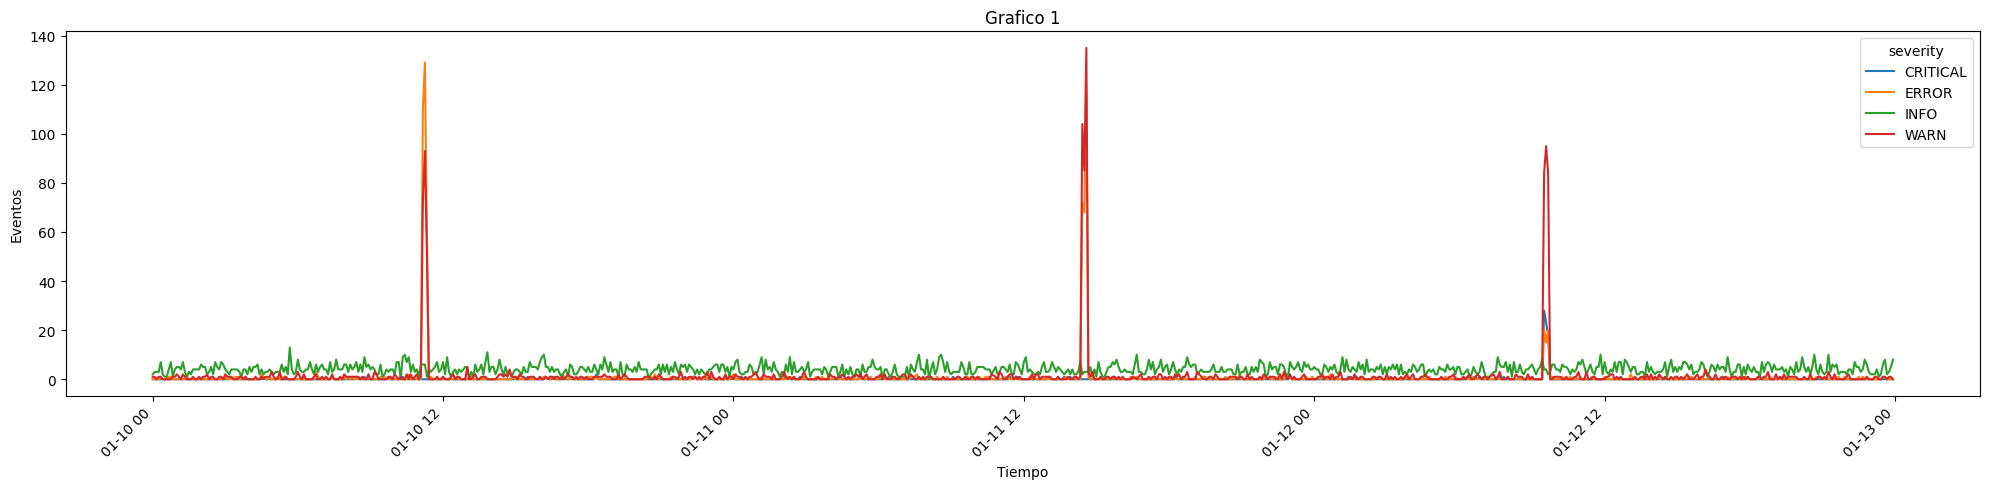

In [36]:
rango_5m = (
    df.groupby([pd.Grouper(key='timestamp_event',freq='5min'),'severity'])
    .size()
    .unstack(fill_value=0)
    )
rango_5m.plot(figsize=(20,5))
plt.title('Grafico 1')
plt.xlabel('Tiempo')
plt.ylabel('Eventos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

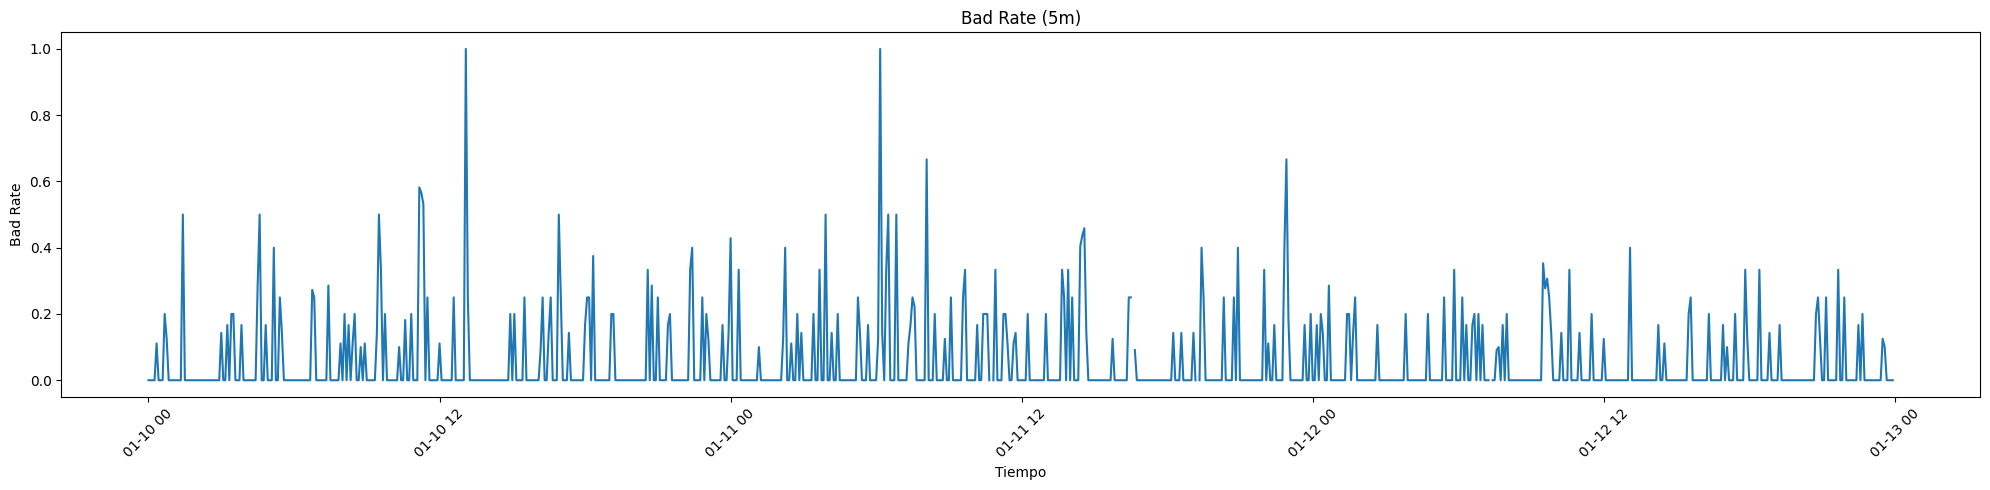

In [54]:
plt.figure(figsize=(20,5))
plt.plot(analisis_temporal.index,analisis_temporal['bad_rate'])
plt.title('Bad Rate (5m)')
plt.xlabel('Tiempo')
plt.ylabel('Bad Rate')
plt.xticks(rotation=45)
plt.tight_layout()

## Conclusion

In [65]:
conclusion = f"""
- Momento crítico: {hora_critica}
- Servicio más afectado: {df_errores_incidente['service_name'].value_counts().index[0]}
- Endpoint más comprometido: {df_errores_incidente['endpoint'].value_counts().index[0]}
- Mensaje dominante: {df_errores_incidente['message'].value_counts().index[0]}
- Comparación clave:
    bad_rate incidente: {analisis_temporal.loc[inicio_incidente,'bad_rate']:.2%}  vs  bad_rate baseline: {bad_rate_baseline:.2%}
    avg_latency incidente: {analisis_temporal.loc[inicio_incidente,'avg_latency_ms']:.2f} ms  vs  avg_latency baseline: {avg_latency_baseline:.2f} ms
"""
print(conclusion)


- Momento crítico: 2026-01-10 11:10:00+00:00
- Servicio más afectado: orders-service
- Endpoint más comprometido: /orders/cancel
- Mensaje dominante: Order creation failed - inventory lock timeout
- Comparación clave:
    bad_rate incidente: 58.20%  vs  bad_rate baseline: 14.00%
    avg_latency incidente: 1589.69 ms  vs  avg_latency baseline: 521.09 ms

